In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd

# Import identified and modelled frequencies and modal shapes

In [3]:
loaded__identified_data_npy = np.load('identified_eigdata.npy', allow_pickle=True).item()
Phi_id = loaded__identified_data_npy['Phi_id']
freq_id = loaded__identified_data_npy['freq_id']
ind_d = loaded__identified_data_npy['ind_d']

print(Phi_id.shape)

loaded_modelled_data_npy = np.load('modelled_eigdata.npy', allow_pickle=True).item()
Phi_M = loaded_modelled_data_npy['Phi_m']
freq_m = loaded_modelled_data_npy['freq_m']
freq_m = freq_m.flatten()

print(Phi_M.shape)

Phi_m = Phi_M[ind_d, :]
Phi_m = Phi_m / np.linalg.norm(Phi_m, axis=0)
print(Phi_m.shape)

n_modes = len(freq_id)
print(n_modes)

(35, 7)
(285, 255)
(35, 255)
7


# MAC of the identified modes

In [4]:
# Calculate and plot the global MAC matrix
MAC = np.zeros((n_modes, n_modes))
for i in range(n_modes):
    for j in range(n_modes):
        MAC[i, j] = (np.abs(Phi_id[:, i].conj().T @ Phi_id[:, j]))**2 / ((Phi_id[:, i].conj().T @ Phi_id[:, i]) * (Phi_id[:, j].conj().T @ Phi_id[:, j]))

# Plot the MAC matrix: Check if the off-diagonal elements are close to zero
fig = px.imshow(MAC, color_continuous_scale='Viridis')
fig.show()

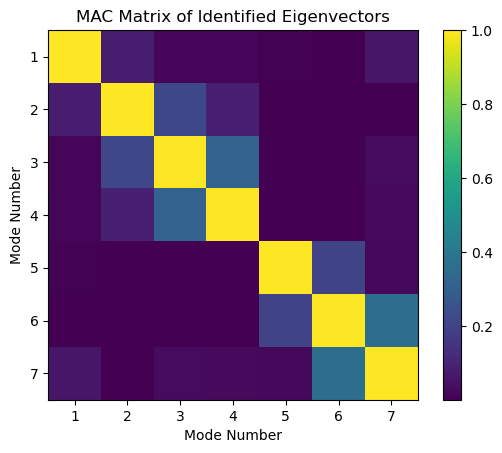

In [11]:
# Calculate and plot the global MAC matrix
MAC = np.zeros((n_modes, n_modes))
for i in range(n_modes):
    for j in range(n_modes):
        MAC[i, j] = (np.abs(Phi_id[:, i].conj().T @ Phi_id[:, j]))**2 / ((Phi_id[:, i].conj().T @ Phi_id[:, i]) * (Phi_id[:, j].conj().T @ Phi_id[:, j]))

# Plot the MAC matrix: Check if the off-diagonal elements are close to zero
fig, ax = plt.subplots()
im = ax.imshow(MAC, cmap='viridis')
plt.colorbar(im)
ax.set_title('MAC Matrix of Identified Eigenvectors')
ax.set_xlabel('Mode Number')
ax.set_ylabel('Mode Number')
ax.set_xticks(np.arange(n_modes))
ax.set_yticks(np.arange(n_modes))
ax.set_xticklabels(np.arange(1, n_modes + 1))
ax.set_yticklabels(np.arange(1, n_modes + 1))
plt.savefig('figures/MAC_matrix.png', dpi=300)
plt.show()

# MAC for identified and modelled modes **pre-updating**

In [6]:
# Compute MAC of identified and modelled modes
n_add_modes = 10 - n_modes
MAC = np.zeros((Phi_id.shape[1] + n_add_modes, Phi_id.shape[1]))   # Initialize MAC matrix
for i in range(Phi_id.shape[1] + n_add_modes):                     # Index over computed modes (larger)
    for j in range(Phi_id.shape[1]):                     # Index over identified modes
        numerator = np.abs(np.conj(Phi_m[:, i]) @ Phi_id[:, j])**2
        denominator = (np.conj(Phi_m[:, i]) @ Phi_m[:, i]) * (np.conj(Phi_id[:, j]) @ Phi_id[:, j])
        MAC[i, j] = numerator / denominator

fig = px.imshow(MAC, color_continuous_scale='Viridis')
fig.show()

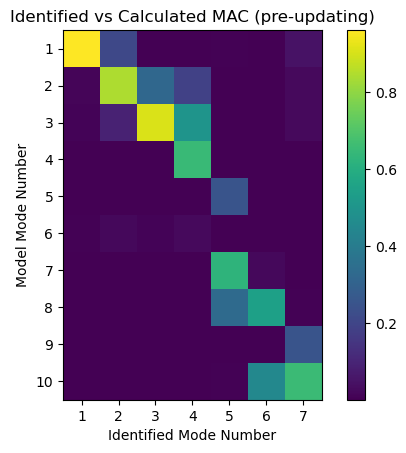

In [13]:
# Compute MAC of identified and modelled modes
n_add_modes = 10 - n_modes
MAC = np.zeros((Phi_id.shape[1] + n_add_modes, Phi_id.shape[1]))   # Initialize MAC matrix
for i in range(Phi_id.shape[1] + n_add_modes):                     # Index over computed modes (larger)
    for j in range(Phi_id.shape[1]):                     # Index over identified modes
        numerator = np.abs(np.conj(Phi_m[:, i]) @ Phi_id[:, j])**2
        denominator = (np.conj(Phi_m[:, i]) @ Phi_m[:, i]) * (np.conj(Phi_id[:, j]) @ Phi_id[:, j])
        MAC[i, j] = numerator / denominator

fig, ax = plt.subplots()
im = ax.imshow(MAC, cmap='viridis', aspect='auto')
plt.colorbar(im)
ax.set_title('Identified vs Calculated MAC (pre-updating)')
ax.set_xlabel('Identified Mode Number')
ax.set_ylabel('Model Mode Number')
ax.set_xticks(np.arange(MAC.shape[1]))
ax.set_yticks(np.arange(MAC.shape[0]))
ax.set_xticklabels(np.arange(1, MAC.shape[1] + 1))
ax.set_yticklabels(np.arange(1, MAC.shape[0] + 1))
ax.set_aspect('equal', adjustable='box')
plt.savefig('figures/MAC_matrix_pre_updating.png', dpi=300)
plt.show()

# Mode pairing

In [8]:
ThMAC = 0.50
# Pairing
modepairs = np.array([], dtype=int).reshape(0, 2)           # preallocate modepairs
for i in range(MAC.shape[1]):                               # for the number of identified modes:     
    if np.max(MAC[:, i]) >= ThMAC:                          # if the max MAC in this col is larger than the threshold
        j = np.argmax(MAC[:, i])                            # find the largest entry i.e. the best matching computed mode and
        modepairs = np.vstack([modepairs, [i + 1, j + 1]])  # write info to "modepairs": i: identified mode nr., j: corresponding model mode nr.

# Make selection matrices to select pairs of modes
L_id = np.zeros((Phi_id.shape[1], modepairs.shape[0]))      # preallocate selection matrix size
L = np.zeros((Phi_m.shape[1], modepairs.shape[0]))
for i in range(modepairs.shape[0]):                         
    L_id[modepairs[i, 0] - 1, i] = 1           # assemble mode selection matrix: identified modes
    L[modepairs[i, 1] - 1, i] = 1              # assemble mode selection matrix: modelled modes

print("Mode pairs (identified mode number, model mode number):")
print(modepairs)

Mode pairs (identified mode number, model mode number):
[[ 1  1]
 [ 2  2]
 [ 3  3]
 [ 4  4]
 [ 5  7]
 [ 6  8]
 [ 7 10]]


# Comparison

In [10]:
# Extract the modelled frequencies corresponding to the mode pairs
freq_m_selected = freq_m[modepairs[:, 1] - 1]

# Calculate percentage difference
difference_percent = (freq_m_selected - freq_id[modepairs[:, 0] - 1]) / freq_id[modepairs[:, 0] - 1] * 100

# Extract MAC values for the paired modes
MAC_value = MAC[modepairs[:, 1] - 1, modepairs[:, 0] - 1]

# Create a DataFrame for better visualization
df = pd.DataFrame({
    'Identified Mode Number': modepairs[:, 0],
    'Model Mode Number': modepairs[:, 1],
    'Identified Frequency (Hz)': freq_id[modepairs[:, 0] - 1],
    'Model Frequency (Hz)': freq_m_selected,
    'Difference (%)': difference_percent,
    'MAC Value': MAC_value
})

df[['Model Frequency (Hz)', 'Difference (%)', 'MAC Value']] = df[['Model Frequency (Hz)', 'Difference (%)', 'MAC Value']].round(2)
display(df)

,Identified Mode Number,Model Mode Number,Identified Frequency (Hz),Model Frequency (Hz),Difference (%),MAC Value
0,1,1,0.32,0.41,28.14,0.96
1,2,2,1.03,1.44,39.45,0.85
2,3,3,3.08,3.02,-2.08,0.92
3,4,4,4.84,4.81,-0.58,0.66
4,5,7,10.83,7.98,-26.27,0.59
5,6,8,13.75,9.89,-28.08,1.00
6,7,10,14.85,10.87,-26.77,0.70
